In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define a function for weighted quantiles
def weighted_quantiles(values, weights, quantiles=[0.5]):
    if len(values) == 0:
        return 0
    else:
        i = np.argsort(values)
        c = np.cumsum(weights[i])
        return values[i[np.searchsorted(c, np.asarray(quantiles) * c[-1])]]

In [3]:
year = 2012
model = 'SIBYLL2.1'
it_split = 38.

# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
KEYS = ['energy', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_zen', 'Gweights']

for key in KEYS:
    sim_file = f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy'
    with open(sim_file, 'rb') as file:
        globals()[key] = np.load(file)

# Directional reconstruction cuts
plane_cut   = (showerplane_zen < np.radians(55))
laputop_cut = (laputop_zen < np.radians(55))
reco_cut    = (reco_pass == 1)

# Energy tier cuts
offset = np.ceil((year - 2011)/2)
TIERS = {
    'Tier 1': (3 <= hits) * (hits < 5),
    'Tier 2': (5 <= hits) * (hits < 10 - offset),
    'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
    'Tier 4': (17 - offset <= hits)
}

# Weights
it_weights = Gweights

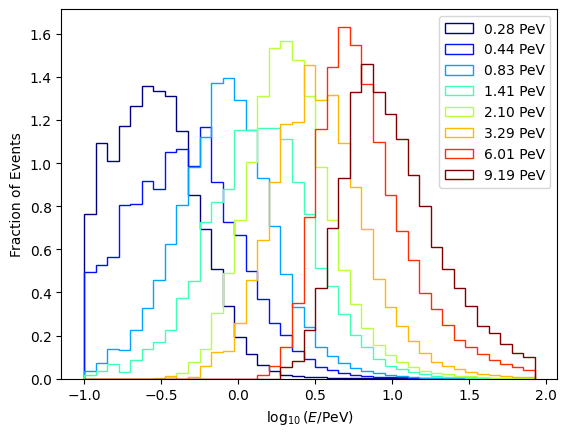

In [5]:
fig, ax = plt.subplots()

h = {}

bins = np.arange(-1,2,.075)
scale = 10**-6

# Set to rainbow sequence
colors = plt.cm.jet(np.linspace(0, 1, 8))
ax.set_prop_cycle(color=colors)

for tier, tier_cut in TIERS.items():

    if tier == 'Tier 1':
        combined_cut = tier_cut * plane_cut
        z_cut = (showerplane_zen <= np.radians(it_split))
    else:
        combined_cut = tier_cut * laputop_cut * reco_cut
        z_cut = (laputop_zen <= np.radians(it_split))

    z_dict = {'lo':combined_cut * z_cut, 'hi':combined_cut * ~z_cut}
    for key, cut in z_dict.items():
   
        # Find median energy for label
        median, sigl, sigr = weighted_quantiles(energy[cut], it_weights[cut], quantiles=[.5,.16,.84]) / 1e6
        label = f'{median:.2f} PeV'

        # Plotting keyword arguments
        kwargs = {'histtype':'step', 'label':label, 'density':True, 'bins':bins}
        
        # Plot
        h[label], bins, _ = ax.hist(np.log10(energy[cut]/1e6), weights=it_weights[cut], **kwargs)
        
ax.set_ylabel('Fraction of Events')
ax.set_xlabel(r'$\log_{10}(E$/PeV)')
ax.legend(loc='upper right')

plt.savefig('energy_distributions_2.pdf')
plt.show()

In [8]:
for key, hist in h.items():
    print(key)
    print(hist)
    print()

0.28 PeV
[7.63294316e-01 1.09186676e+00 1.01048302e+00 1.17442197e+00
 1.26454350e+00 1.35849702e+00 1.33474071e+00 1.30984862e+00
 1.14884354e+00 8.54426276e-01 6.93395589e-01 5.09747256e-01
 3.37072076e-01 1.94981398e-01 1.16185798e-01 6.38704763e-02
 3.58296134e-02 1.95478967e-02 1.19308475e-02 9.12448576e-03
 6.41766220e-03 5.16100924e-03 4.07968884e-03 3.27860793e-03
 2.74263971e-03 1.99162379e-03 1.65286908e-03 1.24953147e-03
 9.81858155e-04 7.11912676e-04 6.00408313e-04 4.52032521e-04
 3.63132248e-04 2.74543807e-04 2.32538723e-04 1.71096361e-04
 1.36136260e-04 1.04222865e-04 8.06512838e-05]

0.44 PeV
[4.96901517e-01 5.28862020e-01 5.64475384e-01 8.06031033e-01
 8.08266995e-01 9.15720826e-01 8.78050274e-01 1.05180510e+00
 1.06737422e+00 9.88606527e-01 1.16807666e+00 9.14571453e-01
 7.27354959e-01 6.66238843e-01 5.01227059e-01 3.69845059e-01
 2.56339012e-01 2.02728920e-01 1.30499786e-01 9.14860343e-02
 5.43328937e-02 4.27338948e-02 2.78063800e-02 1.93663991e-02
 1.40633178e-02 9.4

In [9]:
print(bins)

[-1.    -0.925 -0.85  -0.775 -0.7   -0.625 -0.55  -0.475 -0.4   -0.325
 -0.25  -0.175 -0.1   -0.025  0.05   0.125  0.2    0.275  0.35   0.425
  0.5    0.575  0.65   0.725  0.8    0.875  0.95   1.025  1.1    1.175
  1.25   1.325  1.4    1.475  1.55   1.625  1.7    1.775  1.85   1.925]
